In [1]:
import sklearn
from sklearn.metrics import roc_auc_score
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [115]:
ground_truth=np.array([0, 0, 0, 0, 1, 1, 1, 1])
conf=np.array([0.05, 0.1, 0.3, 0.4, 0.6, 0.75, 0.8, 0.9])
errors=np.array([1,0,0,1,0,0,0,1])
pred = np.where(errors, 1-ground_truth, ground_truth)

g = np.stack([conf, ground_truth, len(conf) * [1], len(conf) * [1], len(conf) * [True]], -1)
p = np.stack([conf, pred, len(conf) * [0], len(conf) * [1], ground_truth == pred], -1)

conf2=np.array([0.4, 0.3, 0.35, 0.45, 0.6, 0.55, 0.5, 0.65])
g2 = np.stack([conf2, ground_truth, len(conf) * [1],  len(conf) * [0], len(conf2) * [True]], -1)
p2 = np.stack([conf2, pred, len(conf) * [0], len(conf) * [0], ground_truth == pred], -1)

df = pd.DataFrame(
    np.concatenate([g, p, g2, p2]),
    columns=['confidence', 'label', 'judge', 'UQ', 'annotation'] ,
)
# df

df["annotation"] = pd.Categorical(df["annotation"].map({0: "Error", 1: "Correct"}), categories=["Correct", "Error"], ordered=True)
df["label"] = pd.Categorical(df["label"].map({0: "Wrong", 1: "Correct"}), categories=["Correct", "Wrong"], ordered=True)
df["judge"] = pd.Categorical(df["judge"].map({0: "Machine", 1: "Human"}), categories=["Human", "Machine"], ordered=True)
df["UQ"] = pd.Categorical(df["UQ"].map({0: "Non-informative", 1: "Informative"}), categories=["Informative", "Non-informative"], ordered=True)

df

,confidence,label,judge,UQ,annotation
0,0.05,Wrong,Human,Informative,Correct
1,0.10,Wrong,Human,Informative,Correct
2,0.30,Wrong,Human,Informative,Correct
3,0.40,Wrong,Human,Informative,Correct
4,0.60,Correct,Human,Informative,Correct
5,0.75,Correct,Human,Informative,Correct
6,0.80,Correct,Human,Informative,Correct
7,0.90,Correct,Human,Informative,Correct
8,0.05,Correct,Machine,Informative,Error
9,0.10,Wrong,Machine,Informative,Correct


In [116]:
df["confidence"].dtype

dtype('float64')

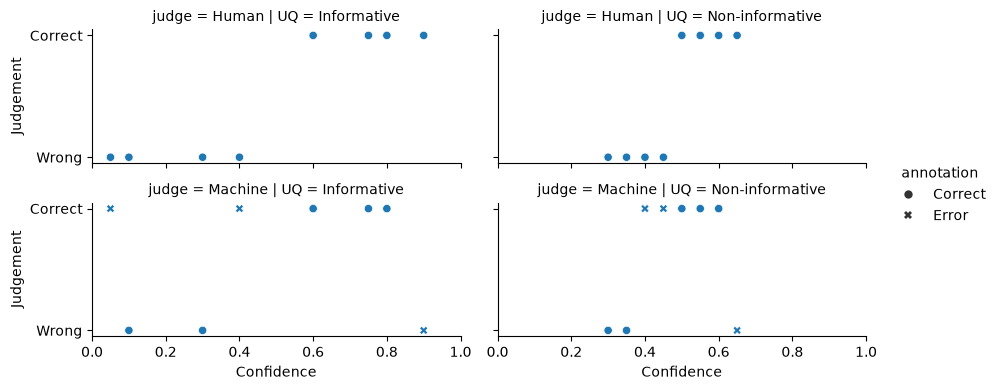

In [123]:

g= sns.relplot(
    df,
    y='label',
    x='confidence',
    # style='label',
    # hue='UQ',
    style='annotation',
    row='judge',
    col='UQ',
)
for ax in g.axes.flat:
    ax.set_xlim(0.0, 1.0)
    # ax.set_xticks(np.arange(0.0, 1.01, 0.2))

g.fig.set_size_inches(10, 4) 
# g.axes[0,0].set_ylabel("Human judgement")
# g.axes[1,0].set_ylabel("Machine judgement")
g.set_ylabels("Judgement")
g.set_xlabels("Confidence")
# g.set(yticklabels=["False", "True"])
_ = g.tight_layout()

In [20]:
def draw(
    ground_truth=np.array([0, 0, 0, 0, 1, 1, 1, 1]),
    conf=np.array([0.05, 0.1, 0.3, 0.4, 0.6, 0.75, 0.8, 0.9]),
    errors=np.array([0,0,0,0,0,0,0,0], dtype=bool)):    
    pred = np.where(errors, 1-ground_truth, ground_truth)

    
    df = pd.DataFrame(
        np.stack([conf, ground_truth, pred, errors], -1),
        columns=['confidence', 'human judgement', 'machine judgement', 'eval error']        
    )
    
    # errors = pred != ground_truth
    # _ = plt.scatter(conf, ground_truth, c='gray', marker='s')
    _ = plt.scatter(conf[ground_truth==1], np.ones_like(conf[ground_truth==1]), c='blue', marker='o', alpha=0.5)
    _ = plt.scatter(conf[ground_truth==0], np.ones_like(conf[ground_truth==0]), c='blue', marker='x', alpha=0.5)

    _ = plt.scatter(conf[np.logical_and(pred==1, pred==ground_truth)], np.zeros_like(conf[np.logical_and(pred==1, pred==ground_truth)]), c='blue', marker='o', alpha=0.5, label='TP')
    _ = plt.scatter(conf[np.logical_and(pred==0, pred==ground_truth)], np.zeros_like(conf[np.logical_and(pred==0, pred==ground_truth)]), c='blue', marker='x', alpha=0.5, label='TN')
    _ = plt.scatter(conf[np.logical_and(pred==1, pred!=ground_truth)], np.zeros_like(conf[np.logical_and(pred==1, pred!=ground_truth)]), c='red', marker='o', alpha=0.5, label='FP')
    _ = plt.scatter(conf[np.logical_and(pred==0, pred!=ground_truth)], np.zeros_like(conf[np.logical_and(pred==0, pred!=ground_truth)]), c='red', marker='x', alpha=0.5, label='FN')
    
    # _ = plt.scatter(conf[pred==0], np.zeros_like(conf[pred==0]), c='red', marker='x', alpha=0.5)

    
    _ = plt.xlabel('Confidence')
    _ = plt.ylabel('Groundtruth judgement')
    _ = plt.yticks([0, 1], ['Machine judgement', 'Human judgement'])
    _ = plt.xlim(-0.1, 1.1)
    _ = plt.xticks([0., 0.2, 0.4, 0.6, 0.8, 1.])
    _ = plt.legend(loc='center right')
    _ = plt.title(f"Judge accuracy {1 - errors.mean():.2f} | AUROC {roc_auc_score(ground_truth, conf):.2f}->{roc_auc_score(pred, conf):.2f}")

In [ ]:
draw(
)

In [ ]:
draw(
    errors=np.array([0, 0, 0, 0, 0, 1, 1, 1], dtype=bool)
)

In [ ]:
draw(
    errors=np.array([0, 0, 1, 1, 1, 0, 0, 0], dtype=bool)
)

In [ ]:
draw(
    errors=np.array([0, 0, 0, 1, 1, 1, 0, 0], dtype=bool)
)

In [ ]:
draw(
    errors=np.array([1, 1, 1, 0, 0, 0, 0, 0], dtype=bool)
)

In [ ]:
draw(
    errors=np.array([1, 0, 0, 1, 0, 0, 0, 1], dtype=bool)
)